In [193]:
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
from typing import Dict, List, Union
import numpy as np
import os
from common import filter_out_failed_iterations, draw_boxplot, select_color

In [194]:
# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Convert DataFrame to a string with no truncation
pd.set_option('display.max_colwidth', None)

In [195]:
#########################################################
### Filepath to the generated CSV data                ###
### Required columns for the 'results' CSV file:      ###
###    1. build_id,                                   ###
###    2. cut_quialified_name,                        ###
###    3. iteration,                                  ###
###    4. prompt_id,                                  ###
###    4. lines_covered,                              ###
###    5. lines_total,                                ###
###    6. branches_covered,                           ###
###    7. branches_total,                             ###
###    8. compilable_test_cases,                      ###
###    9. total_test_cases                            ###
#########################################################

csv_filename = "results.csv" # "testspark-coverage-results.csv"
output_coverage_csv_filename = "testspark_coverage_and_compilability.csv" # "coverage_and_compilability.csv"
output_mean_csv_filename = "testspark_mean_metrics_projects_avg.csv" # "mean_metrics_projects_avg.csv"


# NOTE: 'with-threshold' - M should be > 0
#       'no-threshold'   - M should be <= 0
csv_to_load_filepath  = f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/Llama-32-1B-Instruct/TestSpark/{csv_filename}"
csv_to_store_filepath = \
        f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/with-threshold/{output_coverage_csv_filename}"
        # f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/no-threshold/{output_coverage_csv_filename}"
csv_to_store_mean_metrics_projects_avg_filepath = \
        f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/with-threshold/{output_mean_csv_filename}"
        # f"/home/ubuntu/research-work-2024/evaluation/final/configurations/RQ2/results/no-threshold/{output_mean_csv_filename}"


save_results_in_csv = False

In [196]:
#########################################################################
### Block with function implementations used afterwards in the script ###
#########################################################################

def positive_min_or_zero(x):
    return x[x > 0].min() if not x[x > 0].empty else 0


def add_coverage_and_compilability(data, as_percentage: bool = False):
    """Adds line coverage, branch coverage, and compilability rate to the dataset"""
    data = data[(data['lines_total'] > 0) & (data['branches_total'] > 0) & (data['total_test_cases'] > 0)].copy()

    data['line_coverage'] = data['lines_covered'] / data['lines_total']
    data['branch_coverage'] = data['branches_covered'] / data['branches_total']
    data['compilability_rate'] = data['compilable_test_cases'] / data['total_test_cases']

    if as_percentage:
        data['line_coverage'] = round(100 * data['line_coverage'], 2)
        data['branch_coverage'] = round(100 * data['branch_coverage'], 2)
        data['compilability_rate'] = round(100 * data['compilability_rate'], 2)

    return data


def groupby_project_and_aggregate_line_coverage(data):
    data = data[data['lines_total'] > 0]
    # if no compilable tests generated then cannot reason about their coverage
    data = data[data['total_test_cases'] > 0]

    aggregated_data = data.groupby('build_id').agg(
        lines_covered_min_gt_zero=pd.NamedAgg(column='lines_covered', aggfunc=positive_min_or_zero),
        lines_covered_mean=pd.NamedAgg(column='lines_covered', aggfunc='mean'),
        lines_covered_max=pd.NamedAgg(column='lines_covered', aggfunc='max'),
        lines_total_max=pd.NamedAgg(column='lines_total', aggfunc='max'),
        lines_total_gt_zero=pd.NamedAgg(column='lines_total', aggfunc=(lambda x: (x > 0).sum())),
    )
    # Filter out projects with empty coverage
    gt_zero_data = aggregated_data[aggregated_data['lines_total_max'] > 0]
    # Create coverage filling NaN with zeros
    aggregated_data['line_coverage_mean'] = gt_zero_data['lines_covered_mean'] / gt_zero_data['lines_total_max']
    aggregated_data['line_coverage_mean'] = aggregated_data['line_coverage_mean'].fillna(0.0)
    return aggregated_data


def groupby_project_and_aggregate_branch_coverage(data):
    # NOTE: some projects have valid 0 total branches (i.e., no conditional constructs):
    # data = data[data['branches_total'] > 0]

    # if no compilable tests generated then cannot reason about their coverage
    data = data[data['total_test_cases'] > 0]

    aggregated_data = data.groupby('build_id').agg(
        branches_covered_min_gt_zero=pd.NamedAgg(column='branches_covered', aggfunc=positive_min_or_zero),
        branches_covered_mean=pd.NamedAgg(column='branches_covered', aggfunc='mean'),
        branches_covered_max=pd.NamedAgg(column='branches_covered', aggfunc='max'),
        branches_total_max=pd.NamedAgg(column='branches_total', aggfunc='max'),
        branches_total_gt_zero=pd.NamedAgg(column='branches_total', aggfunc=(lambda x: (x > 0).sum())),
    )
    # Filter out projects with empty coverage
    gt_zero_data = aggregated_data[aggregated_data['branches_total_max'] > 0]
    # Create coverage filling NaN with zeros
    aggregated_data['branch_coverage_mean'] = gt_zero_data['branches_covered_mean'] / gt_zero_data['branches_total_max']
    aggregated_data['branch_coverage_mean'] = aggregated_data['branch_coverage_mean'].fillna(0.0)
    return aggregated_data


def groupby_project_and_aggregate_compilability(data):
    filtered_data = data[data['total_test_cases'] > 0].copy()

    filtered_data['compilability_rate'] = filtered_data['compilable_test_cases'] / filtered_data['total_test_cases']

    aggregated_data = filtered_data.groupby('build_id').agg(
        compilable_test_cases_number_mean=pd.NamedAgg(column='compilable_test_cases', aggfunc='mean'),
        total_test_cases_number_mean=pd.NamedAgg(column='total_test_cases', aggfunc='mean'),
        compilability_rate_mean=pd.NamedAgg(column='compilability_rate', aggfunc='mean'),
    )
    aggregated_data['compilability_rate_mean'] = aggregated_data['compilability_rate_mean'].fillna(0.0)
    return aggregated_data



def merge_metrics(line_coverage, branch_coverage, compilability_rate):
    merged_coverage = pd.merge(
        pd.merge(line_coverage, branch_coverage, on='build_id', how='inner').reset_index(),
        compilability_rate,
        on='build_id',
        how='inner',
    ).reset_index()

    merged_coverage = merged_coverage[[
        'build_id',

        'lines_covered_mean',
        'lines_total_max',
        'line_coverage_mean',
        'lines_total_gt_zero',

        'branches_covered_mean',
        'branches_total_max',
        'branch_coverage_mean',
        'branches_total_gt_zero',

        'compilable_test_cases_number_mean',
        'total_test_cases_number_mean',
        'compilability_rate_mean',
    ]]

    return merged_coverage


def sieve_projects_with_insufficient_coverage_collections_number(merged_coverage, K: int):
    # NOTE: there exist projects with 0 brnahces, thus we cannot filter out projects with 0 branches
    # merged_coverage = merged_coverage[(merged_coverage['lines_total_gt_zero'] >= K) & (merged_coverage['branches_total_gt_zero'] >= K)]
    merged_coverage = merged_coverage[merged_coverage['lines_total_gt_zero'] >= K]
    merged_coverage = merged_coverage.reset_index().drop(columns=['index'])
    print(f"Shape={merged_coverage.shape}")
    return merged_coverage



def leave_projects_from_list(data, project_names: List[str]):
    indicies = data.reset_index()[['index']].to_numpy().flatten().tolist()
    indexes_for_removal = []

    for i in indicies:
        name_found = False

        for name in project_names:
            if (data.loc[i]['build_id'].startswith(name)):
                name_found = True
                break

        if not name_found:
            indexes_for_removal.append(i)

    return data.drop(index=indexes_for_removal)



def transmit_coverage_to_percentage(merged_coverage, round_to: int):
    merged_coverage_percentages = merged_coverage.groupby('build_id').agg(
            lines_covered_mean=pd.NamedAgg(column='lines_covered_mean', aggfunc=(lambda x: round(x, round_to))),
            lines_total_max=pd.NamedAgg(column='lines_total_max', aggfunc=(lambda x: x)),
            line_coverage=pd.NamedAgg(column='line_coverage_mean', aggfunc=(lambda x: round(100 * x, round_to))),

            branches_covered_mean=pd.NamedAgg(column='branches_covered_mean', aggfunc=(lambda x: round(x, round_to))),
            branches_total_max=pd.NamedAgg(column='branches_total_max', aggfunc=(lambda x: x)),
            branch_coverage=pd.NamedAgg(column='branch_coverage_mean', aggfunc=(lambda x: round(100 * x, round_to))),


            compilability_rate=pd.NamedAgg(column='compilability_rate_mean', aggfunc=(lambda x: round(100 * x, round_to)))
        ).reset_index()

    # convert columns to string type
    # columns = ['line_coverage', 'branch_coverage', 'compilability_rate']
    # merged_coverage_percentages[columns] = merged_coverage[columns].astype(str).applymap(lambda x: f"{x}%")

    # projects = [
    #     'epubcheck-49aacb238c',
    #     'frigga-126b52a558',
    #     'jsoup-0121311b1b',
    #     'jsoup-195f484ba5',
    #     'jsoup-1e69577e35',
    #     'jsoup-6ccd158754',
    # ]

    # merged_coverage_percentages[merged_coverage['build_id'].isin(projects)]
    return merged_coverage_percentages



def get_median_coverage(merged_coverage):
    return pd.DataFrame({
        'line_coverage_median': [merged_coverage[['line_coverage']].median()[0]],
        'branch_coverage_median': [merged_coverage[['branch_coverage']].median()[0]],
        'compilability_rate_median': [merged_coverage[['compilability_rate']].median()[0]],
    })


def get_mean_coverage(merged_coverage):
    return pd.DataFrame({
        'mean_line_coverage_projects_avg': [merged_coverage[['line_coverage_mean']].agg('mean')[0]],
        'mean_branch_coverage_projects_avg': [merged_coverage[['branch_coverage_mean']].agg('mean')[0]],
        'mean_compilability_rate_projects_avg': [merged_coverage[['compilability_rate_mean']].agg('mean')[0]],
    })


def get_median_objectives(merged_coverage):
    return pd.DataFrame({
        'lines_total_median': [merged_coverage[['lines_total_max']].median()[0]],
        'branches_total_median': [merged_coverage[['branches_total_max']].median()[0]],
        'compilable_test_cases_number_mean_median': [merged_coverage[['compilable_test_cases_number_mean']].median()[0]],
        'total_test_cases_number_mean_median': [merged_coverage[['total_test_cases_number_mean']].median()[0]],
    })


def get_mean_objectives(merged_coverage):
    return pd.DataFrame({
        'lines_total_avg': [merged_coverage[['lines_total_max']].mean()[0]],
        'branches_total_avg': [merged_coverage[['branches_total_max']].mean()[0]],
        'compilable_test_cases_number_mean_avg': [merged_coverage[['compilable_test_cases_number_mean']].mean()[0]],
        'total_test_cases_number_mean_avg': [merged_coverage[['total_test_cases_number_mean']].mean()[0]],
    })


def get_min_max_objectives(merged_coverage):
    return pd.DataFrame({
        'lines_total_min': [merged_coverage[['lines_total_max']].min()[0]],
        'lines_total_max': [merged_coverage[['lines_total_max']].max()[0]],

        'branches_total_min': [merged_coverage[['branches_total_max']].min()[0]],
        'branches_total_max': [merged_coverage[['branches_total_max']].max()[0]],
    })

In [197]:
#######################
### Read input data ###
#######################

data = pd.read_csv(csv_to_load_filepath)
data.head(10)

,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
0,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,0,llama1b-RQ2,0,9,0,0,0,9,1
1,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,1,llama1b-RQ2,0,9,0,0,0,13,2
2,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,2,llama1b-RQ2,0,9,0,0,0,5,1
3,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,3,llama1b-RQ2,0,9,0,0,0,10,4
4,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,4,llama1b-RQ2,0,9,0,0,0,0,0
5,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,5,llama1b-RQ2,0,9,0,0,0,7,1
6,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,6,llama1b-RQ2,0,9,0,0,0,4,1
7,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,7,llama1b-RQ2,0,9,0,0,0,10,1
8,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,8,llama1b-RQ2,0,9,0,0,0,9,1
9,ConfigMe-7449db4901,ch.jalu.configme.configurationdata.CommentsConfiguration,9,llama1b-RQ2,0,9,0,0,0,8,1


In [198]:
###################################################################
# Preserve only iterations with at least one compilable test case #
###################################################################

# TODO: maybe I shouldn't remove iterations with no compilable test cases for projects that have at least N iterations with >= 1 compilable test case?
data = data[data['compilable_test_cases'] > 0]

In [199]:
#####################################################################
# Filter out project for which the "prompt too long" error occurred #
#####################################################################

# notes_filepath = "/home/ubuntu/projects/tga-pipeline/artifacts/generation-2/basic-prompt-all-projects/notes.txt"
# data= filter_out_failed_iterations(data, notes_filepath)
data.head()

,build_id,cut_quialified_name,iteration,prompt_id,lines_covered,lines_total,branches_covered,branches_total,compilable_test_cases,total_test_cases,used_iterations
38,ConfigMe-cab40d1c3c,ch.jalu.configme.configurationdata.PropertyListBuilder,7,llama1b-RQ2,0,33,0,16,2,12,2
53,ConfigMe-cab40d1c3c,ch.jalu.configme.configurationdata.PropertyListBuilder,22,llama1b-RQ2,0,33,0,16,1,4,2
88,EvalEx-df8eeeb85e,com.ezylang.evalex.parser.Tokenizer,26,llama1b-RQ2,0,260,0,237,1,23,5
91,EvalEx-df8eeeb85e,com.ezylang.evalex.parser.Tokenizer,29,llama1b-RQ2,0,260,0,237,1,19,5
142,database-engine-403a4c0b3b,app.DBApp,18,llama1b-RQ2,0,46,0,4,1,9,1


In [200]:
#####################################################################################
# Count the number of iterations with at least one compilable test case per project #
#####################################################################################

iteration_counts = data[data['compilable_test_cases'] > 0].groupby('build_id')['iteration'].count().reset_index(name='iteration_count')
print(iteration_counts.shape)
iteration_counts

(29, 2)


,build_id,iteration_count
0,ConfigMe-cab40d1c3c,2
1,EvalEx-df8eeeb85e,2
2,database-engine-403a4c0b3b,1
3,dataframe-ec-1109752c4e,2
4,epubcheck-8575a6b1c4,1
5,epubcheck-873d4f5dbb,4
6,formatter-maven-plugin-a6994326aa,2
7,frigga-6b520bbb2e,3
8,grammaticus-d6d4d50ea1,1
9,java-solutions-7a73ea56d0,7


In [201]:
###################################################################################################
# Preserve only projects with at least N iterations that have >= 1 compilable test case generated #
###################################################################################################

N = 10
project_ids_with_enough_compilable_iterations = iteration_counts[iteration_counts['iteration_count'] >= N]['build_id'].to_list()

data = data[data['build_id'].isin(project_ids_with_enough_compilable_iterations)]

distinct_build_ids_count = data['build_id'].nunique()
build_ids = data['build_id'].unique().tolist()
print(f"Distinct build IDs count: {distinct_build_ids_count}")
print(f"Distinct build IDs: {build_ids}")

Distinct build IDs count: 0
Distinct build IDs: []


In [202]:
#############################################################
# Count the number of iterations for the remaining projects #
#############################################################

remaining_iteration_counts = data.groupby('build_id')['iteration'].count().reset_index(name='iteration_count')
print(remaining_iteration_counts.shape)
remaining_iteration_counts

(0, 2)


,build_id,iteration_count


In [203]:
############################################
### Collect line coverage of the dataset ###
############################################

line_coverage = groupby_project_and_aggregate_line_coverage(data)
print("Line Coverage")
line_coverage.head(10)

Line Coverage


,lines_covered_min_gt_zero,lines_covered_mean,lines_covered_max,lines_total_max,lines_total_gt_zero,line_coverage_mean
build_id,,,,,,


In [204]:
##############################################
### Collect branch coverage of the dataset ###
##############################################

branch_coverage = groupby_project_and_aggregate_branch_coverage(data)
print("Branch Coverage")
branch_coverage

Branch Coverage


,branches_covered_min_gt_zero,branches_covered_mean,branches_covered_max,branches_total_max,branches_total_gt_zero,branch_coverage_mean
build_id,,,,,,


In [205]:
####################################################################
### Mean compilability rate for every the project in the dataset ###
####################################################################

compilability_rate = groupby_project_and_aggregate_compilability(data)
print("Compilability Rate")
compilability_rate.head(10)

Compilability Rate


,compilable_test_cases_number_mean,total_test_cases_number_mean,compilability_rate_mean
build_id,,,


In [206]:
##########################################################################################################
### Assemble Total Dataset with mean line coverage, mean branch coverage, and mean compilability rate ###
##########################################################################################################

# merge line and branch coverage over build ids
merged_coverage = merge_metrics(line_coverage, branch_coverage, compilability_rate)

merged_coverage

,build_id,lines_covered_mean,lines_total_max,line_coverage_mean,lines_total_gt_zero,branches_covered_mean,branches_total_max,branch_coverage_mean,branches_total_gt_zero,compilable_test_cases_number_mean,total_test_cases_number_mean,compilability_rate_mean


In [207]:
# Sieve out the projects that had less than K successful coverage collections (both line and branch coverage)
K = 10
merged_coverage = sieve_projects_with_insufficient_coverage_collections_number(merged_coverage, K)
merged_coverage

Shape=(0, 12)


,build_id,lines_covered_mean,lines_total_max,line_coverage_mean,lines_total_gt_zero,branches_covered_mean,branches_total_max,branch_coverage_mean,branches_total_gt_zero,compilable_test_cases_number_mean,total_test_cases_number_mean,compilability_rate_mean


In [208]:
#####################################################
### Filter out projects with less than M coverage ###
#####################################################
# median = 0.1354
M = -1

merged_coverage = merged_coverage[merged_coverage['line_coverage_mean'] >= M]

print(f"Shape: {merged_coverage.shape}")
merged_coverage.head()

Shape: (0, 12)


,build_id,lines_covered_mean,lines_total_max,line_coverage_mean,lines_total_gt_zero,branches_covered_mean,branches_total_max,branch_coverage_mean,branches_total_gt_zero,compilable_test_cases_number_mean,total_test_cases_number_mean,compilability_rate_mean


In [209]:
#############################################################
# Select 10 projects with the number of GitHub stars <= 200 #
#############################################################

# project_names_with_bounded_github_stars = [
#     'ConfigMe',
#     'crowdin-api-client-java',
#     'database-engine',
#     'dataframe-ec',
#     'frigga',
#     'grammaticus',
#     'java-solutions',
#     'java-stellar-sdk',
#     'rcv',
#     'solarpositioning',
# ]

# merged_coverage = leave_projects_from_list(merged_coverage, project_names_with_bounded_github_stars)
# merged_coverage.head()

In [210]:
######################################################################
### Count the number of successful attempts of coverage collection ###
######################################################################

successful_coverage_collections_per_project = merged_coverage[['build_id', 'lines_total_gt_zero', 'branches_total_gt_zero']]
successful_coverage_collections_per_project

,build_id,lines_total_gt_zero,branches_total_gt_zero


In [211]:
###################################
# transform mean into percentages #
###################################

merged_coverage_percentages = transmit_coverage_to_percentage(merged_coverage, 2)
merged_coverage_percentages

,build_id,lines_covered_mean,lines_total_max,line_coverage,branches_covered_mean,branches_total_max,branch_coverage,compilability_rate


In [212]:
########################################
### Save Total Dataset into CSV file ###
########################################

if save_results_in_csv:
    print("Saving results into CSV file...")
    merged_coverage_percentages.to_csv(csv_to_store_filepath, index=False)
else:
    print("Did not save results into CSV file")

Did not save results into CSV file


In [213]:
#####################################
# Median coverage and compilability #
#####################################

median_coverage = get_median_coverage(merged_coverage_percentages)

print(f"M={M}")
median_coverage

M=-1


/tmp/ipykernel_3587860/174291361.py:174: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'line_coverage_median': [merged_coverage[['line_coverage']].median()[0]],
/tmp/ipykernel_3587860/174291361.py:175: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'branch_coverage_median': [merged_coverage[['branch_coverage']].median()[0]],
/tmp/ipykernel_3587860/174291361.py:176: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'compilability_rate_med

,line_coverage_median,branch_coverage_median,compilability_rate_median
0,NaN,NaN,NaN


In [214]:
###################################
# Mean coverage and compilability #
###################################

mean_coverage = get_mean_coverage(merged_coverage)

mean_coverage = mean_coverage.agg(lambda x: round(100 * x, 2))
mean_coverage['min_mean_line_coverage_threshold'] = [M]
mean_coverage

/tmp/ipykernel_3587860/174291361.py:182: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'mean_line_coverage_projects_avg': [merged_coverage[['line_coverage_mean']].agg('mean')[0]],
/tmp/ipykernel_3587860/174291361.py:183: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'mean_branch_coverage_projects_avg': [merged_coverage[['branch_coverage_mean']].agg('mean')[0]],
/tmp/ipykernel_3587860/174291361.py:184: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `se

,mean_line_coverage_projects_avg,mean_branch_coverage_projects_avg,mean_compilability_rate_projects_avg,min_mean_line_coverage_threshold
0,NaN,NaN,NaN,-1


In [215]:
##############################
# Save mean coverage in file #
##############################

if save_results_in_csv:
    print("Saving mean metrics averaged among projects into CSV file...")
    mean_coverage.to_csv(csv_to_store_mean_metrics_projects_avg_filepath, index=False)
else:
    print("Did not save mean metrics averaged among projects into CSV file")

Did not save mean metrics averaged among projects into CSV file


In [216]:
##############################################################################################
# Median lines, branches, compilable test cases, and total test cases number of the projects #
##############################################################################################

median_objectives_number = get_median_objectives(merged_coverage)
median_objectives_number

/tmp/ipykernel_3587860/174291361.py:190: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'lines_total_median': [merged_coverage[['lines_total_max']].median()[0]],
/tmp/ipykernel_3587860/174291361.py:191: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'branches_total_median': [merged_coverage[['branches_total_max']].median()[0]],
/tmp/ipykernel_3587860/174291361.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'compilable_test_case

,lines_total_median,branches_total_median,compilable_test_cases_number_mean_median,total_test_cases_number_mean_median
0,NaN,NaN,NaN,NaN


In [217]:
##############################################################################################
# Mean lines, branches, compilable test cases, and total test cases number of the projects   #
##############################################################################################

mean_objectives_number = get_mean_objectives(merged_coverage)
mean_objectives_number

/tmp/ipykernel_3587860/174291361.py:199: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'lines_total_avg': [merged_coverage[['lines_total_max']].mean()[0]],
/tmp/ipykernel_3587860/174291361.py:200: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'branches_total_avg': [merged_coverage[['branches_total_max']].mean()[0]],
/tmp/ipykernel_3587860/174291361.py:201: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'compilable_test_cases_number_m

,lines_total_avg,branches_total_avg,compilable_test_cases_number_mean_avg,total_test_cases_number_mean_avg
0,NaN,NaN,NaN,NaN


In [218]:
#####################################
# Max and min of lines and branches #
#####################################

min_max_objectives_number = get_min_max_objectives(merged_coverage)
min_max_objectives_number

/tmp/ipykernel_3587860/174291361.py:208: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'lines_total_min': [merged_coverage[['lines_total_max']].min()[0]],
/tmp/ipykernel_3587860/174291361.py:209: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'lines_total_max': [merged_coverage[['lines_total_max']].max()[0]],
/tmp/ipykernel_3587860/174291361.py:211: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'branches_total_min': [merged_coverage[

,lines_total_min,lines_total_max,branches_total_min,branches_total_max
0,NaN,NaN,NaN,NaN


In [219]:
###########################################
# Select N projects with the least metric #
###########################################

# N = 6
# COLUMN = 'line_coverage' # 'line_coverage'

# projects_sorted_by_line_coverage = merged_coverage_percentages.sort_values(by=COLUMN, ascending=True)
# projects_sorted_by_line_coverage.head(N)

In [220]:
merged_coverage_percentages

,build_id,lines_covered_mean,lines_total_max,line_coverage,branches_covered_mean,branches_total_max,branch_coverage,compilability_rate


Projects number: 0


/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/ubuntu/research-work-2024/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ubuntu/research-work-2024/.venv/lib/python3.11

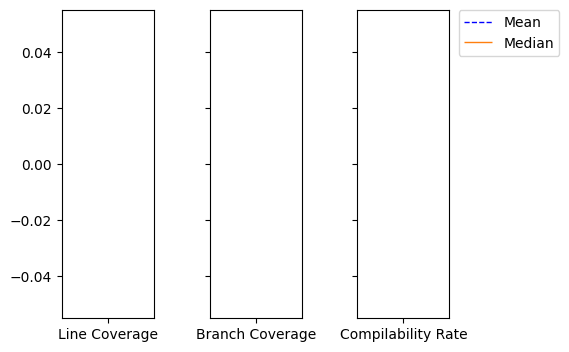

In [221]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(5, 4), sharey=True)

prompt_color = select_color('basic_prompt')

# Line Coverage
bp0 = draw_boxplot(
    merged_coverage_percentages[['line_coverage']].to_numpy().flatten().tolist(),
    labels=['Line Coverage'],
    ax=axs[0],
    boxplotcolors=[prompt_color],
)
# Branch Coverage
bp1 = draw_boxplot(
    data=merged_coverage_percentages[['branch_coverage']].to_numpy().flatten().tolist(),
    labels=['Branch Coverage'],
    ax=axs[1],
    boxplotcolors=[prompt_color],
)
# Compilability Rate
bp2 = draw_boxplot(
    data=merged_coverage_percentages[['compilability_rate']].to_numpy().flatten().tolist(),
    labels=['Compilability Rate'],
    ax=axs[2],
    boxplotcolors=[prompt_color],
)

fig.subplots_adjust(wspace=0.6)

plt.legend([bp0['means'][0], bp0['medians'][0]], ['Mean', 'Median'], loc=(1.1, 0.852)) # loc='upper right'

# fig.suptitle('Results for projects with the number of GitHub stars less than 200', horizontalalignment='center')
projects_count = merged_coverage_percentages.shape[0]

print(f"Projects number: {projects_count}")
plt.show()

In [222]:
# filtered_data = leave_projects_from_list(data, project_names_with_bounded_github_stars)
# filtered_data = add_coverage_and_compilability(filtered_data, as_percentage=True)

# # 'java-stellar-sdk-6e9badb007' has 7 successful iterations
# filtered_data = filtered_data[filtered_data['build_id'] != 'java-stellar-sdk-6e9badb007']

# # filtered_data.groupby('build_id').agg({ 'build_id': 'count' })
# filtered_data.head()

In [223]:
################################################################################################################
# Plot boxplots for every project from the dataset (used only for the projects with small GitHub stars number) #
################################################################################################################

# datasets = []
# labels = []

# for build_id, group in filtered_data.groupby('build_id'):
#     labels.append(build_id)
#     datasets.append(group[['line_coverage']].to_numpy().flatten().tolist())


# # Creating a single shared axis
# fig, ax = plt.subplots()

# for i in range(len(labels)):
#     print(f"{labels[i]}: {datasets[i]}")

# # Creating boxplots
# ax.boxplot(datasets, labels=labels, vert=True, meanline=True, showmeans=True, patch_artist=True)

# # Removing X-axis
# # ax.xaxis.set_visible(False)

# # Setting Y-axis label
# ax.set_ylabel('%')

# # Adding title
# ax.set_title('Multiple Boxplots')
# ax.set_xticklabels(labels, rotation=45, ha='right', fontdict=dict(fontsize=8))
# # Show plot
# plt.show()


In [224]:
# Example
# np.random.seed(10)
# data = np.random.normal(loc=0, scale=1, size=100)

# # Creating the boxplot
# plt.figure(figsize=(8, 6))
# bp = plt.boxplot(data, labels=['ad'], meanline=True, showmeans=True)

# plt.title('Boxplot Example')
# plt.ylabel('Values')
# plt.legend([bp['means'][0], bp['medians'][0]], ['Mean', 'Median'], loc='upper right')

# plt.grid(True)
# plt.show()